Compare neighbor-to-neighbor transitions around repeated items across observed and control datasets. 

The lag-CRP measures the probability of recalling an item at a particular lag **given the current recall position**, conditional on items that remain available for recall. 
Here we follow up on our previous repetition-robust implementation of the Lag-CRP analysis, as well as our Repetition Lag-CRP analysis that separately tracks transitions from repeated items to their neighbors, with a new implementation that allows us to calculate the **Repetition-Neighbor Lag-CRP**.

In this analysis, we calculate transition probabilities from neighbors of the second presentation of repeated items to neighbors of the first presentation of the same repeated items, and/or vice versa.
This allows us to investigate how item repetition affects the contextual features associated with neighboring items in a study list as indicated in free recall.

For repeated items studied at positions $i$ and $j$ with spacing of at least 4 study positions, in this version of the analysis:

1. We only tabulate lag-transitions from recalls of items studied at position $j+1$ and/or $j+2$.
2. We tabulate lags according to the study position of the first presentation of the repeated item, so that we can calculate associations with neighbors of position $i$.

We optionally also or alternatively consider transitions from recalls of items studied at position $i+1$ and/or $i+2$ to neighbors of the repeated item at position $j$.

Adjust `direction` to focus on j→i or i→j neighbor transitions.

Override `ctrl_query` to define alternative control populations.

In [1]:
import os

from jaxcmr.analyses.repneighborcrp import plot_rep_neighbor_crp
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data
from jaxcmr.repetition import make_control_dataset


In [2]:
data_name = "LohnasKahana2014"
data_query = "data['list_type'] == 4"
ctrl_query = "data['list_type'] == 1"
direction = "both"  # options: 'j2i', 'i2j', 'both'
use_lag2 = True


In [3]:
project_root = find_project_root()
data_path = os.path.join(project_root, 'data', f'{data_name}.h5')
data = load_data(data_path)
trial_mask = generate_trial_mask(data, data_query)
control_dataset = make_control_dataset(data, data_query, ctrl_query, 10)
control_mask = generate_trial_mask(control_dataset, data_query)
datasets = [data, control_dataset]
masks = [trial_mask, control_mask]


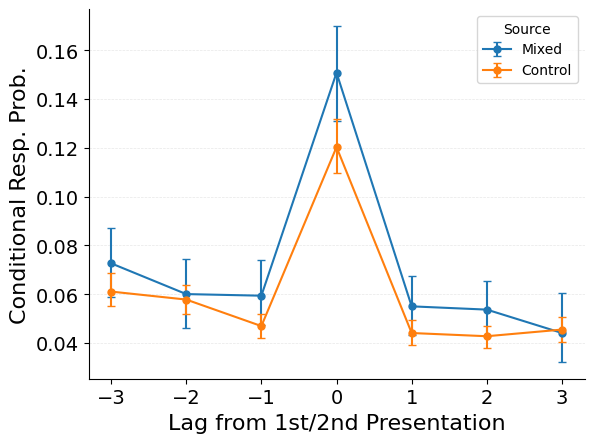

In [4]:
plot_rep_neighbor_crp(
    datasets=datasets,
    trial_masks=masks,
    direction=direction,
    use_lag2=use_lag2,
    contrast_name="Source", 
    labels=["Mixed", "Control"]
);
